**Exploratory Data Analysis (EDA)**
- We will explore the dataset of the "Netflix Prize" & then make suitable processing if required

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Importing the dataset of movie titles**
- Reviewing the data to make changes if any corrupted things are there

In [4]:
with open("../data/movie_titles.csv", "r", encoding="latin1") as f:
    for i in range(10):
        print(f.readline())

1,2003,Dinosaur Planet

2,2004,Isle of Man TT 2004 Review

3,1997,Character

4,1994,Paula Abdul's Get Up & Dance

5,2004,The Rise and Fall of ECW

6,1997,Sick

7,1992,8 Man

8,2004,What the #$*! Do We Know!?

9,1991,Class of Nuke 'Em High 2

10,2001,Fighter



In [5]:
movies = []

with open("../data/movie_titles.csv", "r", encoding="latin1") as f:
    for line in f:
        parts = line.strip().split(",", 2)

        if len(parts) == 3:
            movie_id, year, title = parts
            movies.append([movie_id, year, title])

movie_titles = pd.DataFrame(
    movies,
    columns=["movie_id", "year", "title"]
)

movie_titles.head()

,movie_id,year,title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


In [6]:
movie_titles.shape

(17770, 3)

**Importing the dataset of movie ratings**
- I chose one of the dataset given on kaggle for the movie ratings as keeping in mind the computational efficiency
- Let's review this particular dataset & work on the uncertainities

In [7]:
with open("../data/combined_data_1.txt", "r") as f:
    for i in range(15):
        print(f.readline())

1:

1488844,3,2005-09-06

822109,5,2005-05-13

885013,4,2005-10-19

30878,4,2005-12-26

823519,3,2004-05-03

893988,3,2005-11-17

124105,4,2004-08-05

1248029,3,2004-04-22

1842128,4,2004-05-09

2238063,3,2005-05-11

1503895,4,2005-05-19

2207774,5,2005-06-06

2590061,3,2004-08-12

2442,3,2004-04-14



In [8]:
ratings = []

current_movie = None

with open("../data/combined_data_1.txt", "r") as f:
    
    for line in f:
        
        line = line.strip()

        if ":" in line:
            current_movie = int(line.replace(":", ""))
            
        else:
            user_id, rating, date = line.split(",")

            ratings.append([
                int(user_id),
                current_movie,
                int(rating)
            ])

        # Stop after 500,000 ratings
        if len(ratings) >= 500000:
            break

In [9]:
ratings_df = pd.DataFrame(
    ratings,
    columns=[
        "user_id",
        "movie_id",
        "rating"
    ]
)

ratings_df.head()

,user_id,movie_id,rating
0,1488844,1,3
1,822109,1,5
2,885013,1,4
3,30878,1,4
4,823519,1,3


In [13]:
# Checking the rating dataset shape
ratings_df.shape

(500000, 3)

In [11]:
# Saving the clean dataset for future experimentation
ratings_df.to_csv(
    "../data/ratings_sample.csv",
    index=False
)

In [14]:
# Checking it again
ratings_df.shape

(500000, 3)

**Distribution of ratings**
- For our EDA, it is important to distribute the ratings uniformly

In [15]:
ratings_df["rating"].value_counts().sort_index()

rating
1     25328
2     52351
3    147206
4    174284
5    100831
Name: count, dtype: int64

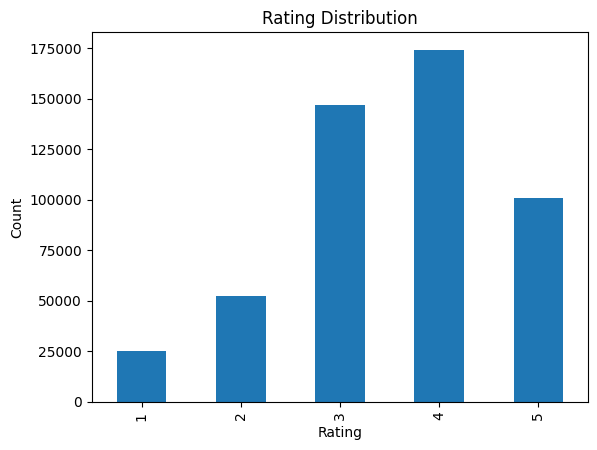

In [16]:
# Plotting it
ratings_df["rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

**Finding the most active users**
- It is a very crucial step to analyze the users, like what proportion of them are mostly active on the platform, in our case "Netflix"  

In [17]:
user_activity = ratings_df.groupby(
    "user_id"
).size()

user_activity.sort_values(
    ascending=False
).head(10)

user_id
305344     143
387418     143
2439493    140
1664010    127
2118461    117
1461435     82
1639792     78
1932594     78
2056022     71
1114324     71
dtype: int64

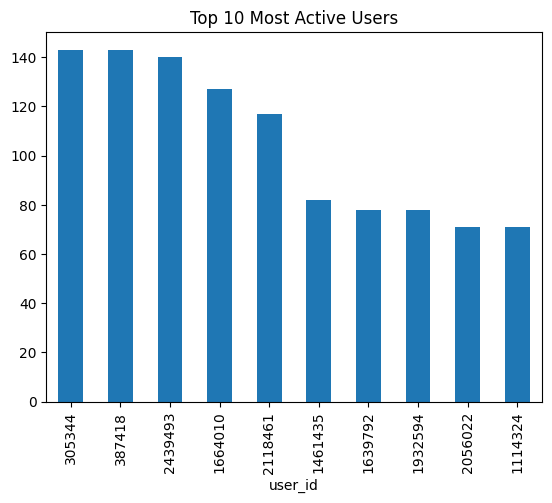

In [18]:
# Plotting it
user_activity.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title("Top 10 Most Active Users")
plt.show()

**Finding the POPULAR movies**
- This step also plays an important role, as it will help the model to decide which movies deserve to be in the recommendations list

In [19]:
movie_popularity = ratings_df.groupby(
    "movie_id"
).size()

movie_popularity.sort_values(
    ascending=False
).head(10)

movie_id
30     118413
28      39752
143     38362
111     30127
118     19240
108     19018
83      18724
58      17405
8       14910
77      13598
dtype: int64

In [21]:
# Merging it with movie names
top_movies = movie_popularity.sort_values(
    ascending=False
).head(10)

top_movies = top_movies.reset_index()

top_movies.columns = [
    "movie_id",
    "num_ratings"
]

movie_titles["movie_id"] = pd.to_numeric(
    movie_titles["movie_id"],
    errors="coerce"
)

top_movies = top_movies.merge(
    movie_titles,
    on="movie_id"
)

top_movies

,movie_id,num_ratings,year,title
0,30,118413,2003,Something's Gotta Give
1,28,39752,2002,Lilo and Stitch
2,143,38362,1997,The Game
3,111,30127,2003,Duplex (Widescreen)
4,118,19240,1985,Rambo: First Blood Part II
5,108,19018,2004,Spartan
6,83,18724,1983,Silkwood
7,58,17405,1996,Dragonheart
8,8,14910,2004,What the #$*! Do We Know!?
9,77,13598,1995,Congo


**Dataset Sparsity**
- It is mandatory to check how sparse the data is for perfect analysis
- The dataset exhibits a sparsity of 98.43%, indicating that users have rated only a very small fraction of the available content, which reflects real-world recommendation systems where user-item interactions are inherently sparse, making recommendation generation a challenging task

In [23]:
num_users = ratings_df["user_id"].nunique()
num_movies = ratings_df["movie_id"].nunique()
num_ratings = len(ratings_df)

sparsity = (
    1 -
    (num_ratings /
     (num_users * num_movies))
) * 100

print(f"Sparsity: {sparsity:.2f}%")
print("Unique Users:",ratings_df["user_id"].nunique())
print("Unique Movies:",ratings_df["movie_id"].nunique())

Sparsity: 98.43%
Unique Users: 215008
Unique Movies: 148
